# Classification Model Using Scikit-learn

## 1. Introduction
In this notebook, I explore the Titanic dataset and build a binary classification model to predict passenger survival.

The notebook is structured as follows:

1. Load and inspect the dataset
2. Create summary statistics and visualizations
3. Define features and target
4. Train a logistic regression model with scikit-learn
5. Evaluate the model using classification metrics

## 2. Load dataset

In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

data = pd.read_csv("../data/titanic.csv")
data.head()  #check the first 5 lines

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
0,1,22.0,1,7.2500,0,0,1,0
1,0,38.0,1,71.2833,1,0,0,1
2,0,26.0,0,7.9250,0,0,1,1
3,0,35.0,1,53.1000,1,0,0,1
4,1,35.0,0,8.0500,0,0,1,0


## 3. Exploration
### 3.1 Inspect dataset

In [9]:
data.columns  #to get all features

Index(['sex', 'age', 'family_size', 'fare', '1st_class', '2nd_class',
       '3rd_class', 'survived'],
      dtype='str')

In [10]:
data.shape  #check the size of the data

(887, 8)

In [11]:
data.info()  #check missing values

<class 'pandas.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          887 non-null    int64  
 1   age          887 non-null    float64
 2   family_size  887 non-null    int64  
 3   fare         887 non-null    float64
 4   1st_class    887 non-null    int64  
 5   2nd_class    887 non-null    int64  
 6   3rd_class    887 non-null    int64  
 7   survived     887 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.6 KB


### 3.2 Data summaries

In [12]:
data.describe() #statistical data

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
count,887.000000,887.000000,887.000000,887.00000,887.000000,887.000000,887.000000,887.000000
mean,0.645998,29.471443,0.908681,32.30542,0.243517,0.207441,0.549042,0.385569
std,0.478480,14.121908,1.615949,49.78204,0.429447,0.405703,0.497870,0.487004
min,0.000000,0.420000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,20.250000,0.000000,7.92500,0.000000,0.000000,0.000000,0.000000
50%,1.000000,28.000000,0.000000,14.45420,0.000000,0.000000,1.000000,0.000000
75%,1.000000,38.000000,1.000000,31.13750,0.000000,0.000000,1.000000,1.000000
max,1.000000,80.000000,10.000000,512.32920,1.000000,1.000000,1.000000,1.000000


In [13]:
data["survived"].value_counts() #show number of each target class.

survived
0    545
1    342
Name: count, dtype: int64

In [14]:
data["survived"].value_counts(normalize=True) #show percentage of each target class.

survived
0    0.614431
1    0.385569
Name: proportion, dtype: float64

#### Observation
1. No missing values;
2. About 38.6% of passengers survived. The target classes are not perfectly balanced.
3. The average passenger age is about 29.5 years, and the median age is 28 years.
4. Most passengers paid relatively low fares, but a few passengers paid much higher fares.
5. Around 54.9% of passengers are in third class.

## 4. EDA/Visualizations

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

### 4.1 Target distribution

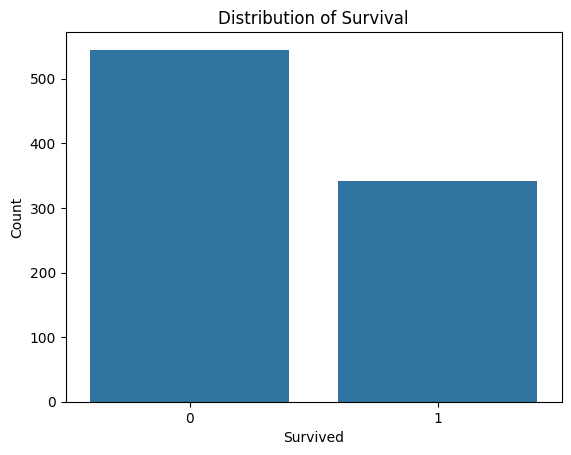

In [16]:
sns.countplot(data=data, x="survived")  
plt.title("Distribution of Survival")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

#### Observation
The count plot helps check whether the two classes are balanced or imbalanced.
It shows that more passengers did not survive than survived. Therefore, accuracy alone may not be enough to evaluate the model later.

### 4.2 Survival by sex

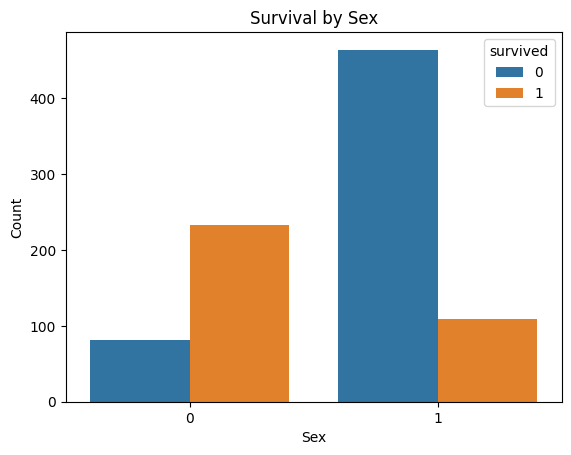

In [17]:
sns.countplot(data=data, x="sex", hue="survived")
plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

In [18]:
data.groupby("sex")["survived"].mean() #Survival rate by sex

sex
0    0.742038
1    0.190227
Name: survived, dtype: float64

#### Observation


The plot shows the relationship between sex and survived.
It suggests that survival differs strongly between the two encoded sex groups.
The groupby result shows the survival rate for each encoded sex group. This helps confirm that `sex` could be an important feature for predicting survival.

### 4.3 Age distribution by survival

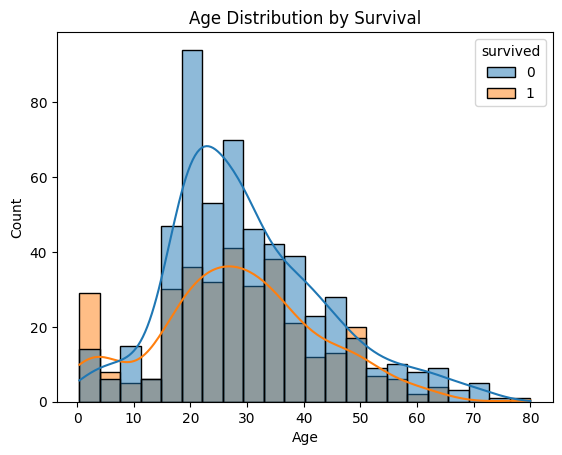

In [19]:
sns.histplot(data=data, x="age", hue="survived", kde=True)
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Observation
This histoplot is suitable here because `age` is a numerical variable.
The plot shows whether survival patterns differ across age groups, for example between children, adults, and older passengers.

### 4.4 Fare distribution

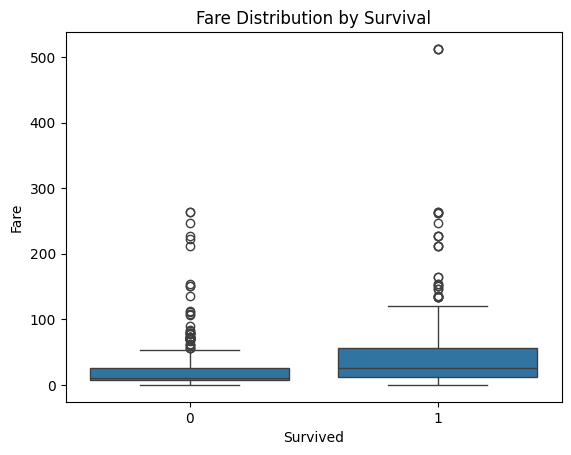

In [20]:
sns.boxplot(data=data, x="survived", y="fare")
plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()

### Observation
This boxplot compares the fare distribution between passengers who survived and passengers who did not survive.  
It is useful here because `fare` is a numerical variable and contains possible outliers.
The plot shows that some passengers paid much higher fares than most others. 
Fare may be related to survival because it can reflect passenger class or cabin location.

### 4.5 Survival by passenger class

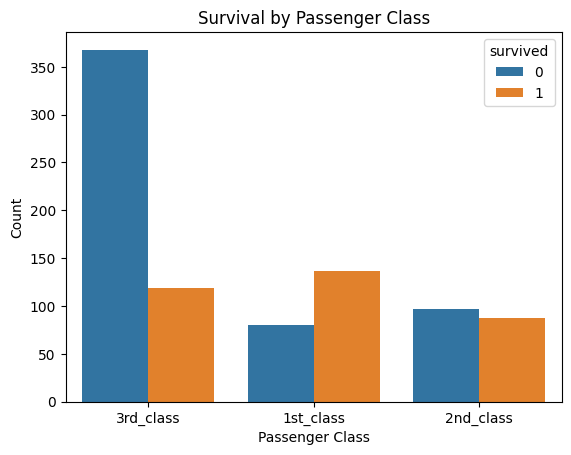

In [21]:
data_plot = data.copy()

data_plot["passenger_class"] = data_plot[["1st_class", "2nd_class", "3rd_class"]].idxmax(axis=1) 

sns.countplot(data=data_plot, x="passenger_class", hue="survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

In [22]:
data_plot.groupby("passenger_class")["survived"].mean() #Survival rate by class

passenger_class
1st_class    0.629630
2nd_class    0.472826
3rd_class    0.244353
Name: survived, dtype: float64

#### Observation
This count plot shows the relationship between passenger class and survival.  
The survival rates by class suggest that passenger class is likely an important feature for predicting survival.

## 5. Model training
### 5.1 Define features and target

features: prepared input training data
target: training answers

In [23]:
FEATURES = ["sex", "age", "family_size", "fare", "1st_class", "2nd_class", "3rd_class"]
TARGET = "survived"

features = data[FEATURES] ##take out the specific columns and make a new table
features.head()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class
0,1,22.0,1,7.2500,0,0,1
1,0,38.0,1,71.2833,1,0,0
2,0,26.0,0,7.9250,0,0,1
3,0,35.0,1,53.1000,1,0,0
4,1,35.0,0,8.0500,0,0,1


In [24]:
target = data[TARGET]
target.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

## 5.2 Prepare dataset
The dataset is splited into a training set and a test set.
The training set is used to train the model, while the test set is kept unseen and used later to evaluate the model.  

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
) 
print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

Training set: 709 samples, Test set: 178 samples


`test_size=0.2` means 20% is used as the test set and 80% is used as the training set.
`random_state=42` makes the split reproducible, so the same rows are selected each time the notebook is run.

## 5.3 Train Logistic Regression with scikit-learn

## 6. Evaluate model

## 7. Conclusion